In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("../data/superstore.csv", encoding="latin-1")

print("Shape:", df.shape)
df.head()


Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Drop missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

print("Cleaned Shape:", df.shape)


Cleaned Shape: (9994, 21)


In [3]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['Weekday'] = df['Order Date'].dt.day_name()

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Day,Weekday
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,8,Tuesday
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,8,Tuesday
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,12,Sunday
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,11,Sunday
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,11,Sunday


In [4]:
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum().reset_index()

monthly_sales.head()


,Order Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


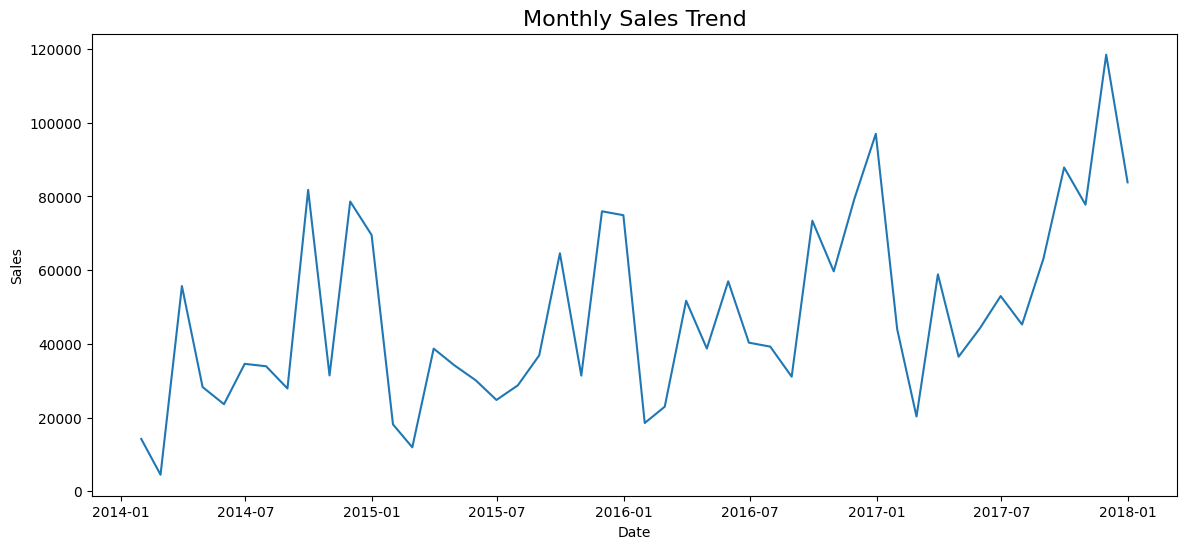

In [5]:
plt.figure(figsize=(14,6))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'])
plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


In [6]:
monthly_sales['Time_Index'] = np.arange(len(monthly_sales))


In [7]:
from sklearn.linear_model import LinearRegression

X = monthly_sales[['Time_Index']]
y = monthly_sales['Sales']

model = LinearRegression()
model.fit(X, y)

print("Model trained successfully!")


Model trained successfully!


In [8]:
future_steps = 12

future_index = np.arange(len(monthly_sales), len(monthly_sales) + future_steps)
future_df = pd.DataFrame({'Time_Index': future_index})

future_predictions = model.predict(future_df)

future_dates = pd.date_range(
    start=monthly_sales['Order Date'].iloc[-1] + pd.offsets.MonthEnd(),
    periods=future_steps,
    freq='M'
)

forecast_df = pd.DataFrame({
    'Order Date': future_dates,
    'Forecasted Sales': future_predictions
})

forecast_df


,Order Date,Forecasted Sales
0,2018-01-31,69957.535798
1,2018-02-28,70859.543330
2,2018-03-31,71761.550862
3,2018-04-30,72663.558395
4,2018-05-31,73565.565927
5,2018-06-30,74467.573459
6,2018-07-31,75369.580992
7,2018-08-31,76271.588524
8,2018-09-30,77173.596056
9,2018-10-31,78075.603589


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

predictions = model.predict(X)

mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))


MAE: 17457.73
RMSE: 21574.53


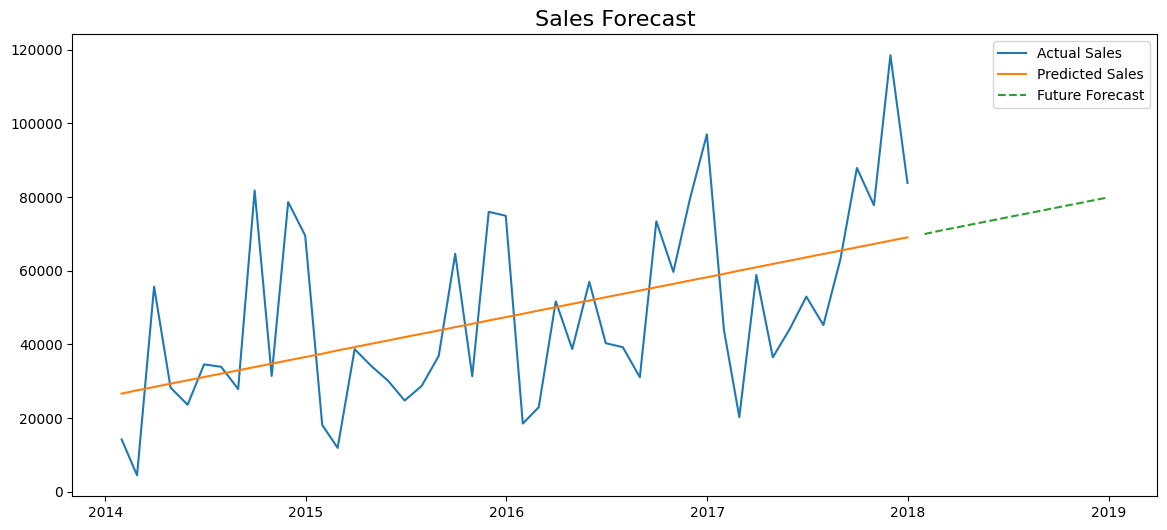

In [10]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales['Order Date'], y, label="Actual Sales")
plt.plot(monthly_sales['Order Date'], predictions, label="Predicted Sales")

plt.plot(forecast_df['Order Date'],
         forecast_df['Forecasted Sales'],
         label="Future Forecast",
         linestyle="dashed")

plt.legend()
plt.title("Sales Forecast", fontsize=16)
plt.show()


In [11]:
forecast_df.to_csv("../data/future_sales_forecast.csv", index=False)

print("Forecast saved successfully!")


Forecast saved successfully!
